<a href="https://colab.research.google.com/github/Laiba-saeed92/Deep-Learning-and-NLP-Projects/blob/main/SMS_Spam_detection_using_NLP_LSTM_BidirecLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from wordcloud import WordCloud , STOPWORDS, ImageColorGenerator

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Embedding, LSTM, Bidirectional, Dropout, GlobalAveragePooling1D

In [ ]:
df= pd.read_csv("/content/SMSSpamCollection",sep ='\t',names=["label", "message"])

FileNotFoundError: [Errno 2] No such file or directory: '/content/SMSSpamCollection'

In [ ]:
df.head()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [ ]:
duplicatedRow = df[df.duplicated()] #To display duplicate rows
print(duplicatedRow[:5])

    label                                            message
103   ham  As per your request 'Melle Melle (Oru Minnamin...
154   ham  As per your request 'Melle Melle (Oru Minnamin...
207   ham  As I entered my cabin my PA said, '' Happy B'd...
223   ham                             Sorry, I'll call later
326   ham                   No calls..messages..missed calls


In [ ]:
df.groupby('label').describe() #to check data is balanced or not

message                                                               
        count unique                                                top freq
label                                                                       
ham      4825   4516                             Sorry, I'll call later   30
spam      747    653  Please call our customer service representativ...    4

In [ ]:
ham_msg= df[df.label=="ham"] #This separates your data into two groups:ham_msg, spam_msg
spam_msg= df[df.label=="spam"]
#This combines all the text messages from each group into one long string —so you can make a word cloud or analyze which words are used most often
ham_msg_text= " ".join(ham_msg.message.to_numpy().tolist()) #This df dataframe is a Pandas Series (not a normal Python list),to_numpy() changes that Pandas Series into a NumPy array.array([hello, how are you, i am good])So now it’s a NumPy array of text strings.
spam_msg_text= " ".join(spam_msg.message.to_numpy().tolist()) #joins a list of words or sentences into one big simple list of string with a space (" ") between each item.Convert my DataFrame column into a normal Python list.



In [ ]:
ham_msg[:5]


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
6,ham,Even my brother is not like to speak with me. ...


In [ ]:
ham_msg_text

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat... Ok lar... Joking wif u oni... U dun say so early hor... U c already then say... Nah I don\'t think he goes to usf, he lives around here though Even my brother is not like to speak with me. They treat me like aids patent. As per your request \'Melle Melle (Oru Minnaminunginte Nurungu Vettam)\' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune I\'m gonna be home soon and i don\'t want to talk about this stuff anymore tonight, k? I\'ve cried enough today. I\'ve been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times. I HAVE A DATE ON SUNDAY WITH WILL!! Oh k...i\'m watching here:) Eh u remember how 2 spell his name... Yes i did. He v naughty make until i v wet. Fine if that\x92s the way u feel. That\x92s th

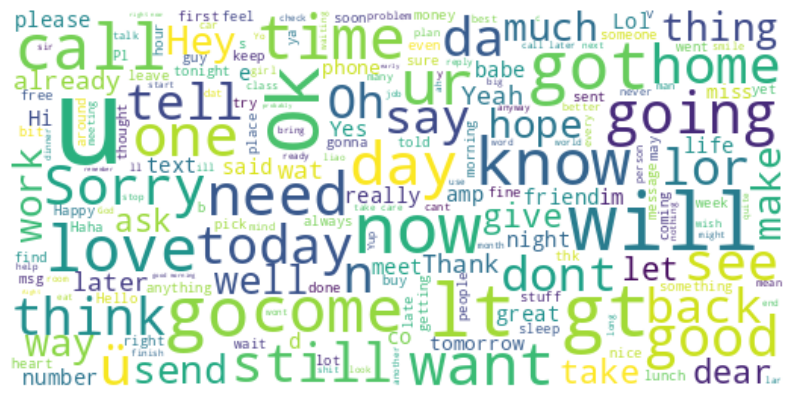

In [ ]:
#Wordcloud of ham messages
ham_msg_wordcloud= WordCloud(width=512, height=250, background_color="white", stopwords=STOPWORDS, max_font_size=80).generate(ham_msg_text)
plt.figure(figsize=(10,8)) #width = 10 inches, height = 8 inches
plt.imshow(ham_msg_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

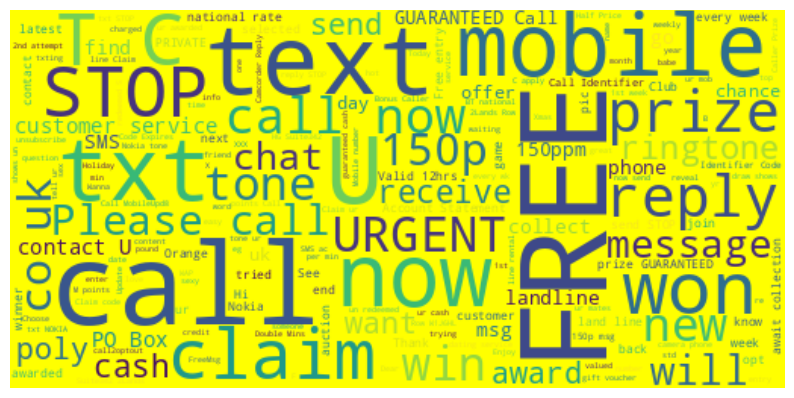

In [ ]:
#Wordcloud of ham messages
spam_msg_wordcloud= WordCloud(width=512, height=250, background_color="yellow", stopwords=STOPWORDS, max_font_size=80).generate(spam_msg_text)
plt.figure(figsize=(10,8)) #width = 10 inches, height = 8 inches
plt.imshow(spam_msg_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

/tmp/ipython-input-3766476904.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df.label, data=df, palette=["orange", "blue"])


<Axes: xlabel='label', ylabel='count'>

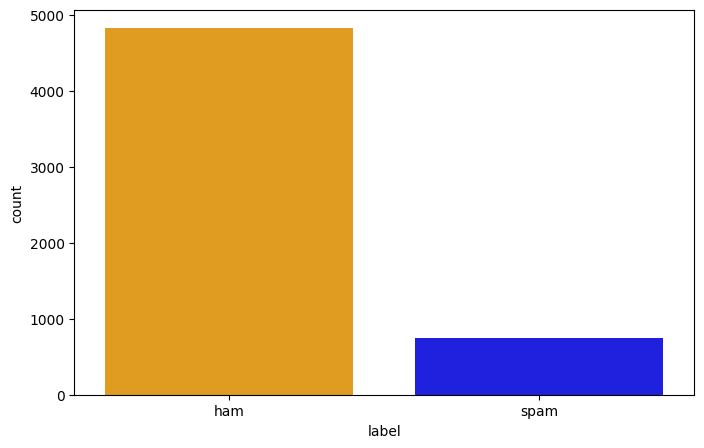

In [ ]:
#We can see imbalance data with plotting
plt.figure(figsize=(8,5))
sns.countplot(x=df.label, data=df, palette=["orange", "blue"])



In [ ]:
## one way to fix it is to downsample the ham msg to reduce the unequality between two classes
ham_msg_df= ham_msg.sample(n=len(spam_msg), random_state=42)
spam_msg_df=spam_msg
print(ham_msg_df.shape, spam_msg_df.shape)


(747, 2) (747, 2)


/tmp/ipython-input-3532216042.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=msg_df.label, data=msg_df, palette=["orange", "blue"])


Text(0.5, 0, 'Message types')

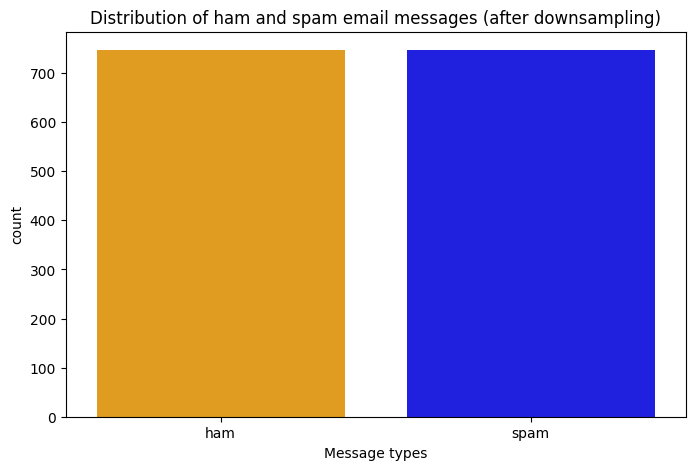

In [ ]:
## Create a dataframe with these ham and spam msg
msg_df=pd.concat([ham_msg_df, spam_msg_df]).reset_index(drop=True)
plt.figure(figsize=(8,5))
sns.countplot(x=msg_df.label, data=msg_df, palette=["orange", "blue"])
plt.title('Distribution of ham and spam email messages (after downsampling)')
plt.xlabel('Message types')

In [ ]:
## Get length column for each text
msg_df['text_length']= msg_df['message'].apply(len) #When you used apply(len), it counts characters, not words,For each message, count how many characters (letters, spaces, punctuation, etc.) it contains
msg_df['text_length']
labels=msg_df.groupby('label')["text_length"].mean() ##Calculate average length by label types
labels

 #Average length of ham is 69 and spam is 138

,text_length
label,
ham,69.427041
spam,138.670683


In [ ]:
max_lengths = msg_df.groupby('label')['text_length'].max() #find the max length of message for both ham and spam
print(max_lengths) #The longest message of ham has 444 characters, not 444 words.


label
ham     444
spam    223
Name: text_length, dtype: int64


In [ ]:
#Test training splitting of dataset
#First map ham label as 0 and spam as 1 as machine understands numeric values
msg_df['label']=(msg_df['label'].astype(str) # make sure values are strings
                               .str.strip()  # remove spaces
                               .str.lower()  # lowercase for consistency
                               .map({'ham':0 , 'spam':1 }).values) ## map to numeric



In [ ]:
print(msg_df['label'].unique())


[0 1]


In [ ]:
print(msg_df)

      label                                            message  text_length
0         0  If i not meeting ü all rite then i'll go home ...           84
1         0  I.ll always be there, even if its just in spir...          103
2         0                   Sorry that took so long, omw now           32
3         0  I thk 50 shd be ok he said plus minus 10.. Did...           84
4         0  Dunno i juz askin cos i got a card got 20% off...          111
...     ...                                                ...          ...
1489      1  Want explicit SEX in 30 secs? Ring 02073162414...           90
1490      1  ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...          158
1491      1  Had your contract mobile 11 Mnths? Latest Moto...          160
1492      1  REMINDER FROM O2: To get 2.50 pounds free call...          147
1493      1  This is the 2nd time we have tried 2 contact u...          160

[1494 rows x 3 columns]


In [ ]:
#Now train test split
train_msg, test_msg, train_labels, test_labels= train_test_split(msg_df['message'], msg_df['label'], test_size=0.2, random_state=42)

In [ ]:
## Defining pre-processing hyperparameters
max_len=50 #95–98% of messages fit entirely,Only very few long ones get truncated,You don’t want every box to be extra large — it wastes space.Most items are small.A few are very large
vocab_size=500 #vocab_size = the number of unique words (tokens) that your tokenizer will keep in its “dictionary,If your entire dataset has 10,000 unique words, your true vocabulary size = 10,000
#But in practice, we don’t use all — we usually take only the top N most frequent words (e.g., 500, 1000, or 10,000).
trunc_type='post'
padding_type='post'
oov_tok="<OOV>" #Keep only the 500 most frequent words, and replace all others with <OOV> (out of vocabulary token)


In [ ]:
'''The vocab_size you pass to the Tokenizer does not define how many words exist —
it defines how many words to keep after the tokenizer has learned all of them,Tokenizer scans your whole dataset and finds, say, 8,724 unique words.
You tell it: vocab_size = 500 meaning: “Keep only the 500 most frequent words.
In real-world text data, many words are:Rare, typosMisspellings,Names, URLs, emojis, random characters,Words that appear only once or twice
Memory and model size
If you use the entire vocabulary, say 50,000 unique words:
Your embedding layer will have 50,000 × embedding_dim parameters.
(If embedding_dim = 100 → that’s 5 million weights!)
It increases RAM usage, training time, and risk of overfitting.'''

'The vocab_size you pass to the Tokenizer does not define how many words exist —\nit defines how many words to keep after the tokenizer has learned all of them,Tokenizer scans your whole dataset and finds, say, 8,724 unique words.\nYou tell it: vocab_size = 500 meaning: “Keep only the 500 most frequent words.\nIn real-world text data, many words are:Rare, typosMisspellings,Names, URLs, emojis, random characters,Words that appear only once or twice\nMemory and model size\nIf you use the entire vocabulary, say 50,000 unique words:\nYour embedding layer will have 50,000 × embedding_dim parameters.\n(If embedding_dim = 100 → that’s 5 million weights!)\nIt increases RAM usage, training time, and risk of overfitting.'

In [ ]:
#Tokenize all the words
tokenizer= Tokenizer(num_words= vocab_size, char_level= False, oov_token= oov_tok)
tokenizer.fit_on_texts(train_msg)
word_index=(tokenizer.word_index)
word_index

{'<OOV>': 1,
 'to': 2,
 'you': 3,
 'a': 4,
 'i': 5,
 'call': 6,
 'the': 7,
 'your': 8,
 'u': 9,
 'is': 10,
 'for': 11,
 'and': 12,
 'now': 13,
 'free': 14,
 'or': 15,
 '2': 16,
 'on': 17,
 'have': 18,
 'in': 19,
 'ur': 20,
 'of': 21,
 '4': 22,
 'txt': 23,
 'from': 24,
 'are': 25,
 'with': 26,
 'text': 27,
 'me': 28,
 'this': 29,
 'stop': 30,
 'just': 31,
 'mobile': 32,
 'my': 33,
 'reply': 34,
 'claim': 35,
 'get': 36,
 'will': 37,
 'only': 38,
 'be': 39,
 'no': 40,
 'it': 41,
 'www': 42,
 'that': 43,
 'new': 44,
 'so': 45,
 'send': 46,
 'we': 47,
 'out': 48,
 'at': 49,
 'not': 50,
 'cash': 51,
 'prize': 52,
 'our': 53,
 'do': 54,
 'if': 55,
 't': 56,
 'can': 57,
 'please': 58,
 'won': 59,
 'go': 60,
 '1': 61,
 'all': 62,
 "i'm": 63,
 'win': 64,
 'uk': 65,
 'but': 66,
 '150p': 67,
 'who': 68,
 'nokia': 69,
 'been': 70,
 'tone': 71,
 'by': 72,
 'urgent': 73,
 'msg': 74,
 '50': 75,
 'what': 76,
 'know': 77,
 'when': 78,
 'want': 79,
 'co': 80,
 'phone': 81,
 'com': 82,
 '16': 83,
 'lt': 

In [ ]:
import joblib
joblib.dump(tokenizer, 'tokenizer.pkl')


['tokenizer.pkl']

In [ ]:
#Check how many total unique words
vocab_size=len(tokenizer.word_index)
print("Total unique words in dataset:", vocab_size) #So your dataset has 4123 unique words

Total unique words in dataset: 4123


In [ ]:
print("max_len =", max_len)
print("type of max_len =", type(max_len))


max_len = 50
type of max_len = <class 'int'>


In [ ]:
## Sequencing and padding on training and testing
training_sequences= tokenizer.texts_to_sequences(train_msg)
training_sequences
training_padding= pad_sequences(training_sequences, maxlen=max_len, padding=padding_type, truncating=trunc_type) #or can write as padding='post', truncating='post' if we didnt already inialize the variables
testing_sequences= tokenizer.texts_to_sequences(test_msg)
testing_padding= pad_sequences(testing_sequences, maxlen=max_len, padding=padding_type, truncating=trunc_type)

In [ ]:
print(training_padding.shape)
print(testing_padding.shape)
print(training_padding[0])
print(testing_padding[0])

(1195, 50)
(299, 50)
[  5   1   2 292 115   2 458  22  28   2   1   1 313  33   1   1  19 151
 459   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
[ 73 335   1  11   1   1 136  10   8   1  94  16 113  48 219   1   1 225
  42   1  82 155  10   4   1   1   1  11   3   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [ ]:
# Before padding length
print(len(training_sequences[0]), len(training_sequences[1]))
# After padding length
print(len(training_padding[0]), len(training_padding[1]))

20 4
50 50


**Logistic Regression**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# TF-IDF features
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=2)
X_train_tfidf = vectorizer.fit_transform(train_msg)
X_test_tfidf = vectorizer.transform(test_msg)

# Logistic Regression
model = LogisticRegression(max_iter=1000, C=1, class_weight='balanced')
model.fit(X_train_tfidf, train_labels)

# Evaluate
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", model.score(X_test_tfidf, test_labels))
print(classification_report(test_labels, y_pred))

Accuracy: 0.9464882943143813
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       145
           1       0.96      0.94      0.95       154

    accuracy                           0.95       299
   macro avg       0.95      0.95      0.95       299
weighted avg       0.95      0.95      0.95       299



In [ ]:
for msg, pred in zip(test_msg[:20], y_pred[:20]):
    print(f"[{'SPAM' if pred==1 else 'HAM'}] {msg}")


[SPAM] URGENT, IMPORTANT INFORMATION FOR O2 USER. TODAY IS YOUR LUCKY DAY! 2 FIND OUT WHY LOG ONTO HTTP://WWW.URAWINNER.COM THERE IS A FANTASTIC SURPRISE AWAITING FOR YOU
[SPAM] Panasonic & BluetoothHdset FREE. Nokia FREE. Motorola FREE & DoubleMins & DoubleTxt on Orange contract. Call MobileUpd8 on 08000839402 or call 2optout
[SPAM] Do you want a new Video handset? 750 any time any network mins? UNLIMITED TEXT? Camcorder? Reply or Call now 08000930705 for del Sat AM
[SPAM] Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 JANINExx Calls£1/minMobsmoreLKPOBOX177HP51FL
[SPAM] 09066362231 URGENT! Your mobile No 07xxxxxxxxx won a £2,000 bonus caller prize on 02/06/03! this is the 2nd attempt to reach YOU! call 09066362231 ASAP!
[HAM] Will do. Was exhausted on train this morning. Too much wine and pie. You sleep well too
[HAM] Oh Howda gud gud.. Mathe en samachara chikku:-)
[HAM] Dear Hero,i am leaving to qatar tonite for an a

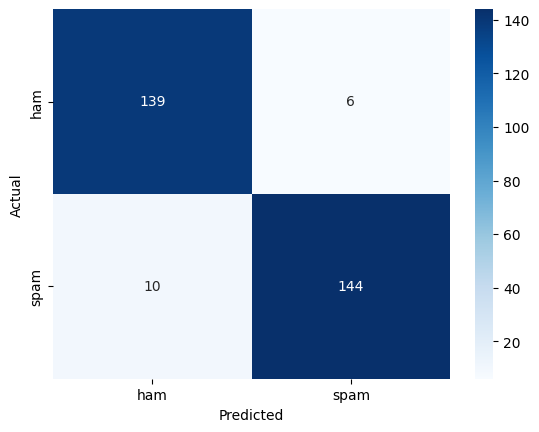

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()



In [ ]:
#Save the model
import joblib
joblib.dump(model, 'LogReg_spam_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')


['tfidf_vectorizer.pkl']

**Dense Spam Detection Model**

In [ ]:
#Dense model architecture
model= Sequential()
model.add(Embedding(vocab_size, 50, input_length=max_len))
model.add(GlobalAveragePooling1D()) #But in Keras, you must add layers using .add(), not call them directly
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
model.summary()
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Fitting a dense spam detector model
early_stop=EarlyStopping(monitor='val_loss', patience=3)
history= model.fit(training_padding, train_labels, epochs=30, validation_data=(testing_padding, test_labels), callbacks=[early_stop], verbose=2)

Epoch 1/30
38/38 - 5s - 144ms/step - accuracy: 0.5222 - loss: 0.6620 - val_accuracy: 0.6355 - val_loss: 0.6142
Epoch 2/30
38/38 - 0s - 4ms/step - accuracy: 0.7900 - loss: 0.5316 - val_accuracy: 0.8227 - val_loss: 0.4545
Epoch 3/30
38/38 - 0s - 4ms/step - accuracy: 0.8603 - loss: 0.3833 - val_accuracy: 0.8662 - val_loss: 0.3419
Epoch 4/30
38/38 - 0s - 8ms/step - accuracy: 0.9021 - loss: 0.2756 - val_accuracy: 0.9030 - val_loss: 0.2522
Epoch 5/30
38/38 - 0s - 4ms/step - accuracy: 0.9397 - loss: 0.1916 - val_accuracy: 0.9398 - val_loss: 0.2018
Epoch 6/30
38/38 - 0s - 4ms/step - accuracy: 0.9540 - loss: 0.1497 - val_accuracy: 0.9398 - val_loss: 0.1880
Epoch 7/30
38/38 - 0s - 4ms/step - accuracy: 0.9632 - loss: 0.1242 - val_accuracy: 0.9365 - val_loss: 0.1807
Epoch 8/30
38/38 - 0s - 4ms/step - accuracy: 0.9665 - loss: 0.1147 - val_accuracy: 0.9498 - val_loss: 0.1509
Epoch 9/30
38/38 - 0s - 4ms/step - accuracy: 0.9682 - loss: 0.0946 - val_accuracy: 0.9431 - val_loss: 0.1716
Epoch 10/30
38/38

In [ ]:
#Evaluating model on test data
model.evaluate(testing_padding, test_labels)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9504 - loss: 0.1374 


[0.16380251944065094, 0.9431437849998474]

In [ ]:
from tensorflow.keras.models import save_model
# If you still have the model variable in memory
model.save("Dense_Detection.keras", save_format="keras")
print("✅ Model saved successfully!")


✅ Model saved successfully!


In [ ]:
metrics = pd.DataFrame(history.history)
# Rename column
metrics.rename(columns = {'loss': 'Training_Loss', 'accuracy': 'Training_Accuracy', 'val_loss': 'Validation_Loss', 'val_accuracy': 'Validation_Accuracy'}, inplace = True)


In [ ]:
metrics

,Training_Accuracy,Training_Loss,Validation_Accuracy,Validation_Loss
0,0.522176,0.661955,0.635451,0.614169
1,0.789958,0.531593,0.822742,0.454518
2,0.860251,0.383263,0.866221,0.341881
3,0.902092,0.275591,0.903010,0.252242
4,0.939749,0.191634,0.939799,0.201773
5,0.953975,0.149689,0.939799,0.188013
6,0.963180,0.124200,0.936455,0.180713
7,0.966527,0.114662,0.949833,0.150929
8,0.968201,0.094588,0.943144,0.171596
9,0.974059,0.081617,0.943144,0.163416


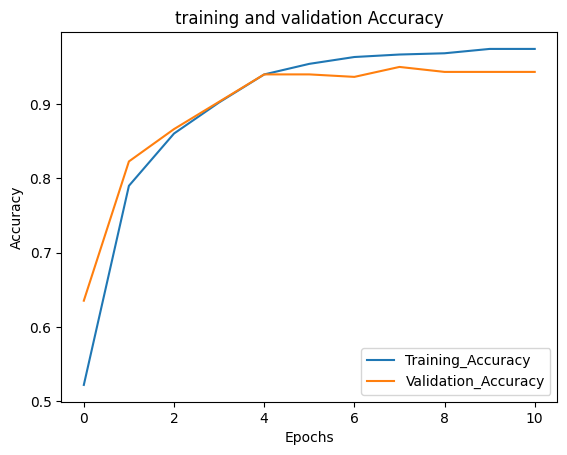

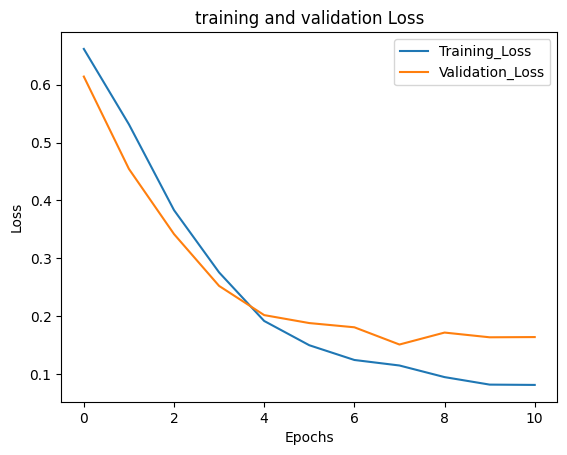

In [ ]:
#Plotting the accuracy and losses
def plot_graph1(var1, var2, string):
  metrics[[var1, var2]].plot()
  plt.title("training and validation "+string)
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([var1,var2])
plot_graph1("Training_Accuracy", "Validation_Accuracy", "Accuracy")
plot_graph1("Training_Loss", "Validation_Loss", "Loss")

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip #You need the pretrained GloVe embeddings, which are public and free from Stanford.
!unzip glove.6B.zip                               #Load GloVe (100-dimensional vectors trained on 6B tokens of Wikipedia + Gigaword)


--2025-11-01 16:11:40--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-11-01 16:11:40--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-11-01 16:11:40--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
import os
print(os.listdir())  # should show glove.6B.100d.txt



['.config', 'Dense_Spam_Detection.keras', 'glove.6B.300d.txt', 'glove.6B.zip', 'tfidf_vectorizer.pkl', 'SMSSpamCollection', 'glove.6B.200d.txt', 'glove.6B.100d.txt', 'LogReg_spam_model.pkl', 'tokenizer.pkl', 'glove.6B.50d.txt', 'sample_data']


In [ ]:
embedding_dim = 100
embedding_index = {}
with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector


**Long Short Term Memory Model**

In [ ]:
#LSTM hyperparameters
n_lstm = 128
#drop_lstm =0.2

#LSTM Spam detection architecture
model1 = Sequential()
model1.add(Embedding(vocab_size, 100,weights=[embedding_matrix], input_length=max_len, trainable=True))
model1.add(LSTM(n_lstm, activation='relu', dropout=0.2,return_sequences=True))#return_sequences=True is giving error due to wrong dimensions
model1.add(GlobalAveragePooling1D())
model1.add(Dense(64, activation='relu')),
model1.add(Dropout(0.2)),
model1.add(Dense(1, activation='sigmoid'))
model1.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics=['accuracy'])
num_epochs = 30
early_stop = EarlyStopping(monitor='val_loss', patience=3)
history = model1.fit(training_padding, train_labels, epochs=num_epochs, validation_data=(testing_padding, test_labels),callbacks =[early_stop], verbose=2)
model1.save('LSTM_Spam_Detection.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
38/38 - 9s - 241ms/step - accuracy: 0.7690 - loss: 1.5761 - val_accuracy: 0.8528 - val_loss: 0.7548
Epoch 2/30
38/38 - 0s - 12ms/step - accuracy: 0.8510 - loss: 6.2182 - val_accuracy: 0.6823 - val_loss: 0.5413
Epoch 3/30
38/38 - 0s - 9ms/step - accuracy: 0.8753 - loss: 0.4378 - val_accuracy: 0.8997 - val_loss: 0.7914
Epoch 4/30
38/38 - 0s - 9ms/step - accuracy: 0.9096 - loss: 0.2509 - val_accuracy: 0.9130 - val_loss: 0.4125
Epoch 5/30
38/38 - 0s - 9ms/step - accuracy: 0.9389 - loss: 0.1713 - val_accuracy: 0.9298 - val_loss: 34.3866
Epoch 6/30
38/38 - 0s - 9ms/step - accuracy: 0.9565 - loss: 0.1218 - val_accuracy: 0.9431 - val_loss: 2448.8772
Epoch 7/30
38/38 - 0s - 9ms/step - accuracy: 0.8745 - loss: 3.2181 - val_accuracy: 0.9498 - val_loss: 0.3106
Epoch 8/30
38/38 - 1s - 16ms/step - accuracy: 0.9364 - loss: 0.2519 - val_accuracy: 0.9130 - val_loss: 0.2575
Epoch 9/30
38/38 - 0s - 9ms/step - accuracy: 0.9389 - loss: 0.1954 - val_accuracy: 0.9298 - val_loss: 0.2208
Epoch 10/30

In [ ]:
model1.evaluate(testing_padding, test_labels)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9547 - loss: 0.1538 


[0.20295056700706482, 0.9431437849998474]

In [ ]:
model.save("LSTM_Spam_Detection.keras", save_format="keras")
print("✅ Model saved successfully!")


✅ Model saved successfully!


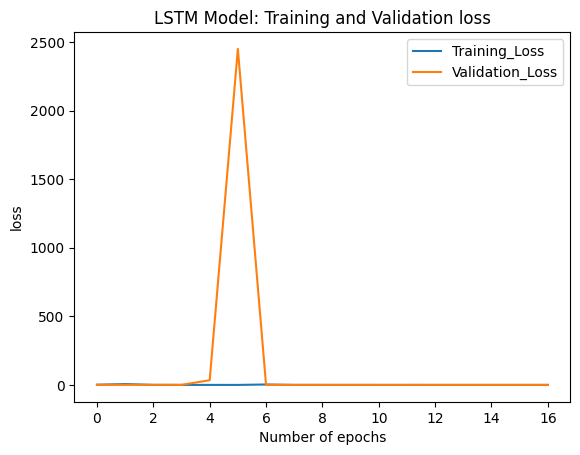

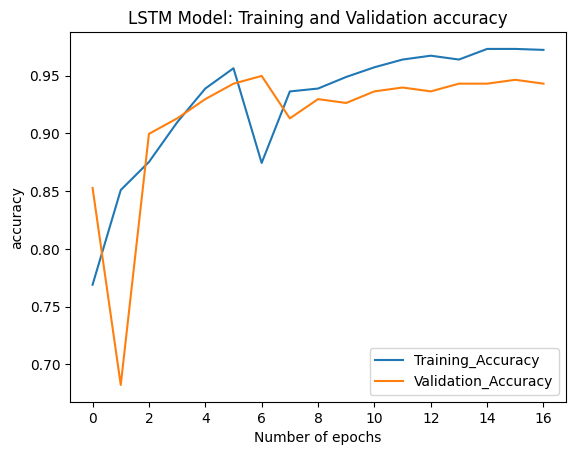

In [ ]:
# Create a dataframe
metrics = pd.DataFrame(history.history)# Rename column
metrics.rename(columns = {'loss': 'Training_Loss', 'accuracy': 'Training_Accuracy',
                         'val_loss': 'Validation_Loss', 'val_accuracy': 'Validation_Accuracy'}, inplace = True)
def plot_graphs1(var1, var2, string):
    metrics[[var1, var2]].plot()
    plt.title('LSTM Model: Training and Validation ' + string)
    plt.xlabel ('Number of epochs')
    plt.ylabel(string)
    plt.legend([var1, var2])
plot_graphs1('Training_Loss', 'Validation_Loss', 'loss')
plot_graphs1('Training_Accuracy', 'Validation_Accuracy', 'accuracy')

**Bi.Directional Long Short Term Memory (BiDirectional LSTM)**

In [ ]:
# Biderectional LSTM Spam detection architecture
model2 = Sequential()
model2.add(Embedding(vocab_size,100, weights=[embedding_matrix], input_length=max_len, trainable=True))
model2.add(Bidirectional(LSTM(128, activation='relu', dropout=0.2, return_sequences=True)))
model2.add(GlobalAveragePooling1D()),
model2.add(Dense(64, activation='relu')),
model2.add(Dropout(0.2)),
model2.add(Dense(1, activation='sigmoid'))
model2.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics=['accuracy'])
# Training
num_epochs = 30
early_stop = EarlyStopping(monitor='val_loss', patience=3)
history = model2.fit(training_padding, train_labels, epochs=num_epochs,
                    validation_data=(testing_padding, test_labels),callbacks =[early_stop], verbose=2)
model2.save('BiLSTM_Spam_Detection.h5')

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


38/38 - 12s - 317ms/step - accuracy: 0.6477 - loss: 6.4398 - val_accuracy: 0.6221 - val_loss: 0.5919
Epoch 2/30
38/38 - 1s - 17ms/step - accuracy: 0.8795 - loss: 235.1906 - val_accuracy: 0.8696 - val_loss: 2.1697
Epoch 3/30
38/38 - 1s - 13ms/step - accuracy: 0.8444 - loss: 0.4596 - val_accuracy: 0.8863 - val_loss: 0.4225
Epoch 4/30
38/38 - 1s - 14ms/step - accuracy: 0.9071 - loss: 0.2584 - val_accuracy: 0.8997 - val_loss: 0.3564
Epoch 5/30
38/38 - 1s - 13ms/step - accuracy: 0.9331 - loss: 0.2005 - val_accuracy: 0.9130 - val_loss: 0.4089
Epoch 6/30
38/38 - 1s - 15ms/step - accuracy: 0.9372 - loss: 0.1635 - val_accuracy: 0.9164 - val_loss: 0.4071
Epoch 7/30
38/38 - 1s - 15ms/step - accuracy: 0.9498 - loss: 0.1475 - val_accuracy: 0.9231 - val_loss: 0.5003


In [ ]:
model2.evaluate(testing_padding, test_labels)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9430 - loss: 0.3429


[0.5002641677856445, 0.9230769276618958]

In [ ]:
model.save("BiLSTM_Spam_Detection.keras", save_format="keras")
print("✅ Model saved successfully!")


✅ Model saved successfully!


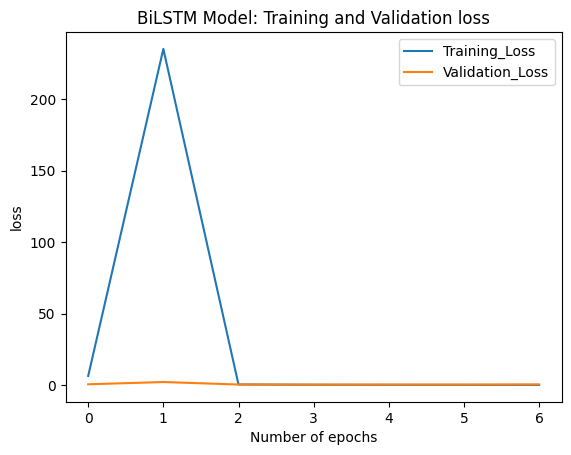

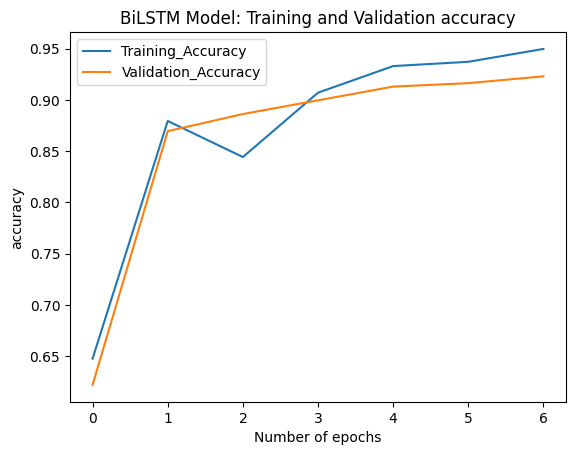

In [ ]:
# Create a dataframe
metrics = pd.DataFrame(history.history)# Rename column
metrics.rename(columns = {'loss': 'Training_Loss', 'accuracy': 'Training_Accuracy',
                         'val_loss': 'Validation_Loss', 'val_accuracy': 'Validation_Accuracy'}, inplace = True)
def plot_graphs1(var1, var2, string):
    metrics[[var1, var2]].plot()
    plt.title('BiLSTM Model: Training and Validation ' + string)
    plt.xlabel ('Number of epochs')
    plt.ylabel(string)
    plt.legend([var1, var2])# Plot
plot_graphs1('Training_Loss', 'Validation_Loss', 'loss')
plot_graphs1('Training_Accuracy', 'Validation_Accuracy', 'accuracy')

In [ ]:
import tensorflow as tf
print(tf.__version__)


2.19.0
